Loading processed CSV...
Data loaded.
Translating station names to Pinyin...
All stations successfully mapped to Pinyin.
Successfully filtered for 'Dongsi' station, total 58857 rows.
Plotting 8-year PM2.5 trend for 'Dongsi'...


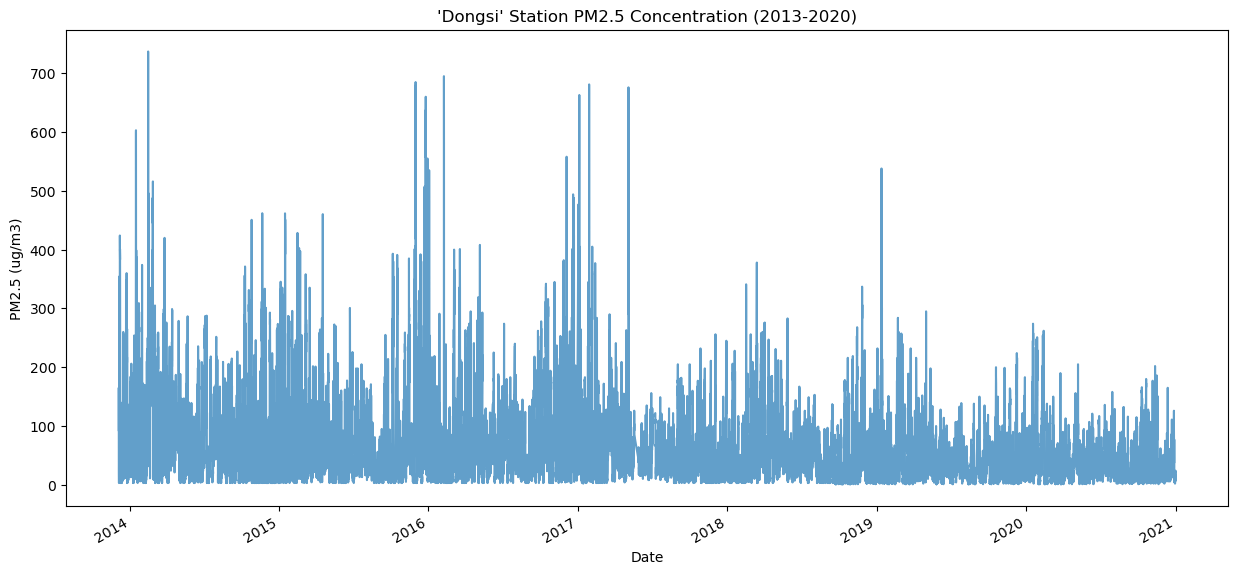


--- Data preview for 'Dongsi' ---
                    station  pm2.5
datetime                          
2013-12-05 01:00:00  Dongsi   93.0
2013-12-05 02:00:00  Dongsi  165.0
2013-12-05 03:00:00  Dongsi  133.0
2013-12-05 04:00:00  Dongsi   85.0
2013-12-05 05:00:00  Dongsi   29.0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 步骤 1: 加载你的干净数据 ---
print("Loading processed CSV...")
df = pd.read_csv('beijing_pm25_2013_2020_processed.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print("Data loaded.")

# --- 步骤 2: 创建中文到拼音的 "映射字典" ---
# 这是你数据中所有监测站的拼音翻译
station_map = {
    '东四': 'Dongsi', '天坛': 'Tiantan', '官园': 'Guanyuan', '万寿西宫': 'Wanshouxigong',
    '奥体中心': 'Aotizhongxin', '农展馆': 'Nongzhanguan', '万柳': 'Wanliu',
    '北部新区': 'Beibuxinqu', '植物园': 'Zhiwuyuan', '丰台花园': 'Fengtaihuayuan',
    '云岗': 'Yungang', '古城': 'Gucheng', '房山': 'Fangshan', '大兴': 'Daxing',
    '亦庄': 'Yizhuang', '通州': 'Tongzhou', '顺义': 'Shunyi', '昌平': 'Changping',
    '门头沟': 'Mentougou', '平谷': 'Pinggu', '怀柔': 'Huairou', '密云': 'Miyun',
    '延庆': 'Yanqing', '定陵': 'Dingling', '八达岭': 'Badaling', '密云水库': 'Miyunshuiku',
    '东高村': 'Donggaocun', '永乐店': 'Yongledian', '榆垡': 'Yufa', '琉璃河': 'Liulihe',
    '前门': 'Qianmen', '永定门内': 'Yongdingmennei', '西直门北': 'Xizhimenbei',
    '南三环': 'Nansanhuan', '东四环': 'Dongsihuan'
}

# --- 步骤 3: "翻译" 整个 'station' 列 ---
print("Translating station names to Pinyin...")
df['station'] = df['station'].map(station_map)

# (可选) 检查是否有未被翻译的站 (显示为 NaN)
unmapped = df['station'].isnull().sum()
if unmapped > 0:
    print(f"Warning: {unmapped} rows had unmapped stations and became NaN.")
    # 删除这些未翻译的行
    df.dropna(subset=['station'], inplace=True)
else:
    print("All stations successfully mapped to Pinyin.")

# --- 步骤 4: 为 ARIMA 建模选择一个站 (使用拼音) ---
# 我们选择 "Dongsi" 站
station_name_pinyin = 'Dongsi'
df_station = df[df['station'] == station_name_pinyin].copy()

# 将 datetime 设为索引
df_station.set_index('datetime', inplace=True)

print(f"Successfully filtered for '{station_name_pinyin}' station, total {len(df_station)} rows.")

# --- 步骤 5: 绘图 (现在全是英文，不需要中文字体配置) ---
print(f"Plotting 8-year PM2.5 trend for '{station_name_pinyin}'...")
df_station['pm2.5'].plot(
    figsize=(15, 7),
    title=f"'{station_name_pinyin}' Station PM2.5 Concentration (2013-2020)",
    alpha=0.7
)
plt.ylabel('PM2.5 (ug/m3)') # 使用英文单位
plt.xlabel('Date') # 添加英文x轴标签
plt.show()

print(f"\n--- Data preview for '{station_name_pinyin}' ---")
print(df_station.head())

Resampling data to daily averages...
Resampling complete. New data shape: (2551,)
Plotting daily average data...


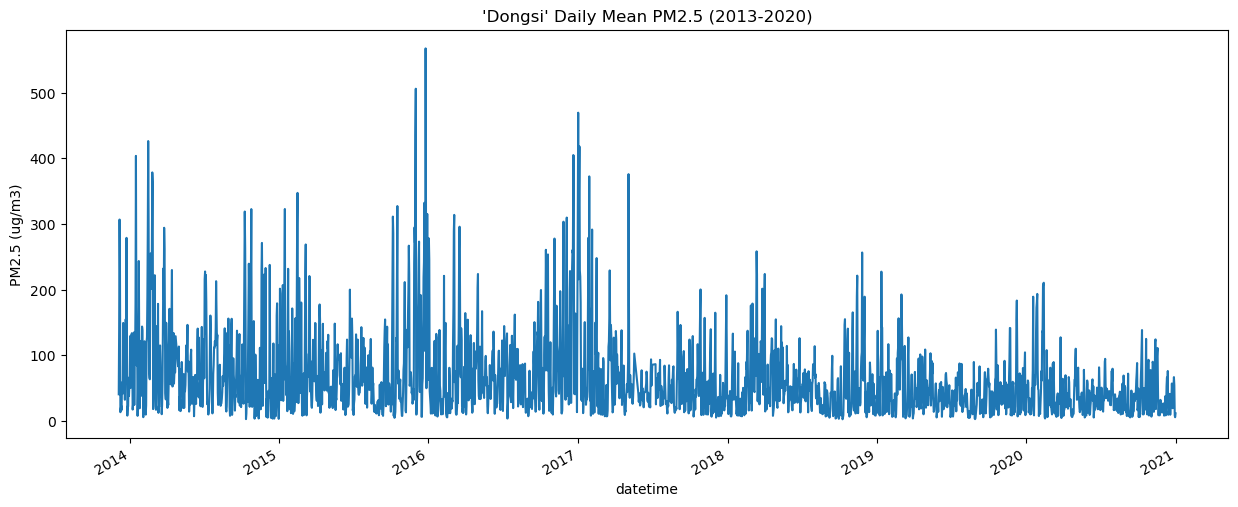


--- Running Augmented Dickey-Fuller Test on Daily Data ---
ADF Statistic: -5.121964498406008
p-value: 1.266122507369352e-05
Critical Values:
	1%: -3.432944516713937
	5%: -2.8626862482960957
	10%: -2.567380191580307

Test Result: The series is STATIONARY (p-value <= 0.05).
We can proceed with ARIMA.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# --- 步骤 1: 重采样为 "日平均数据" ---

# df_station 是你上一步得到的 "Dongsi" 站的小时数据
# 我们使用 .resample('D') 按天(Day)重采样
# 然后使用 .mean() 计算每天的平均值
print("Resampling data to daily averages...")
df_daily = df_station['pm2.5'].resample('D').mean()

# 删除因重采样可能产生的空值 (比如某一天24小时都没有数据)
df_daily = df_daily.dropna()

print(f"Resampling complete. New data shape: {df_daily.shape}")

# --- 步骤 2: 可视化 "日平均数据" ---
print("Plotting daily average data...")
df_daily.plot(
    figsize=(15, 6),
    title=f"'{station_name_pinyin}' Daily Mean PM2.5 (2013-2020)"
)
plt.ylabel('PM2.5 (ug/m3)')
plt.show()

# --- 步骤 3: 运行 ADF 测试来检查平稳性 ---

print("\n--- Running Augmented Dickey-Fuller Test on Daily Data ---")

# 运行 ADF 测试
# 'autolag='AIC'' 会自动帮我们选择最佳的滞后阶数
adf_result = adfuller(df_daily, autolag='AIC')

print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"\t{key}: {value}")

# --- 步骤 4: 解释 ADF 测试结果 ---
if adf_result[1] > 0.05:
    print("\nTest Result: The series is NON-STATIONARY (p-value > 0.05).")
    print("We MUST apply 'differencing' before using ARIMA.")
else:
    print("\nTest Result: The series is STATIONARY (p-value <= 0.05).")
    print("We can proceed with ARIMA.")

Plotting ACF and PACF charts...


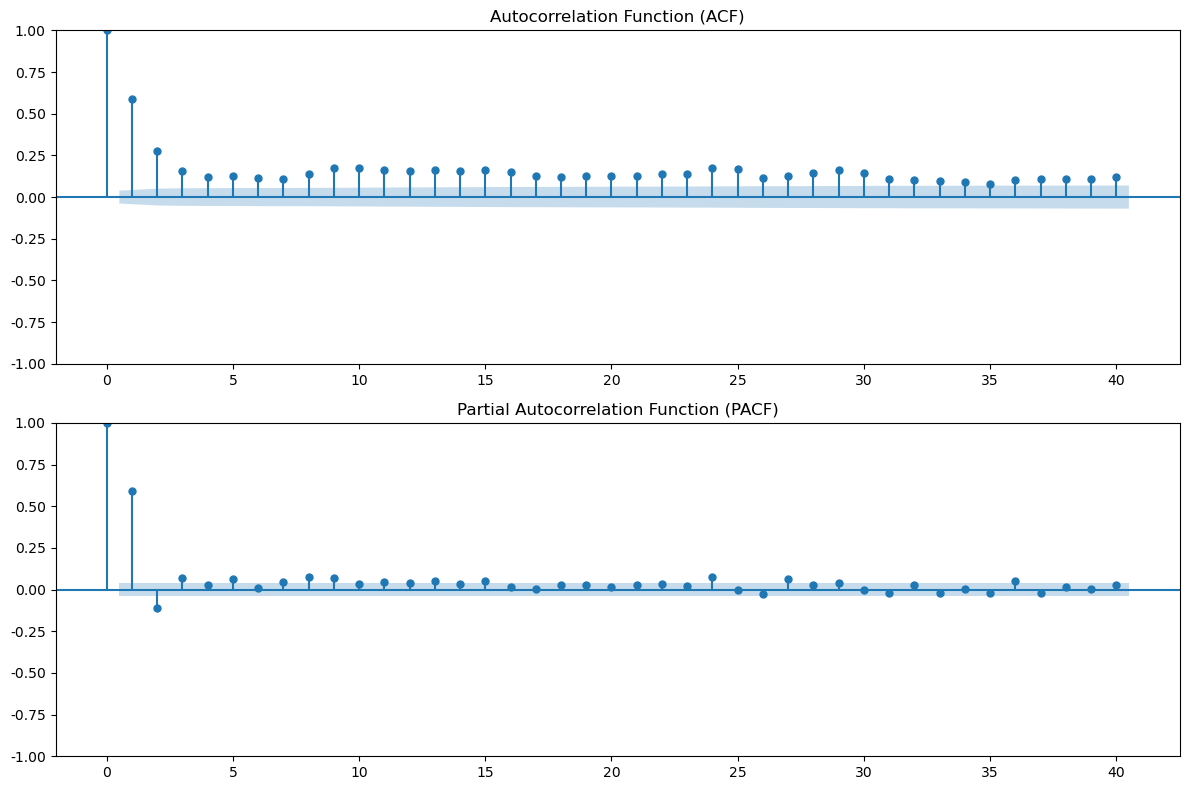

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# df_daily 是你上一步得到的 "日平均" 数据

print("Plotting ACF and PACF charts...")

# 创建一个 2x1 的图表布局
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 1. 绘制 ACF 图
#    lags=40 表示我们看过去40天的相关性
plot_acf(df_daily, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# 2. 绘制 PACF 图
plot_pacf(df_daily, lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout() # 自动调整布局
plt.show()

In [ ]:
import pmdarima as pm
from pmdarima import model_selection

# df_daily 是你上一步的 "日平均" 数据

print("Starting automatic ARIMA parameter search...")
print("This may take a few minutes...\n")

# 运行 auto_arima
# trace=True 会打印出它尝试的每一个模型和它的 AIC 分数
auto_model = pm.auto_arima(
    df_daily, 
    start_p=1,      # p 的起始搜索值
    max_p=7,       # p 的最大搜索值 (我们根据 PACF 猜 7, 所以 10 足够了)
    start_q=0,      # q 的起始搜索值
    max_q=5,        # q 的最大搜索值
    
    d=0,            # 关键：我们从 ADF 测试中已经确定 d=0
    
    seasonal=False, # 关键：我们先不考虑"季节性"
                    # 我们只想先找到 p 和 q
    
    trace=True,     # 打印每一步的尝试结果
    stepwise=True,  # 启用“逐步搜索”，速度更快
    suppress_warnings=True, # 忽略警告
    error_action='ignore'   # 忽略有问题的模型
)

# 打印搜索摘要
print(f"\n--- AutoARIMA Search Complete ---")
print(auto_model.summary())

Starting automatic ARIMA parameter search...
This may take a few minutes...

Performing stepwise search to minimize aic
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=27567.510, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=30221.109, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=28571.754, Time=0.09 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=27568.647, Time=0.04 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.w

 ARIMA(1,0,1)(0,0,0)[0]             : AIC=27567.853, Time=0.15 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,1)(0,0,0)[0]             : AIC=27559.364, Time=0.29 sec


...

 ARIMA(4,0,0)(0,0,0)[0]             : AIC=27440.509, Time=0.27 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,2)(0,0,0)[0]             : AIC=27140.775, Time=0.77 sec


d:\anaconda\envs\project312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=27155.305, Time=1.31 sec

Best model:  ARIMA(3,0,1)(0,0,0)[0]          
Total fit time: 5.668 seconds

--- AutoARIMA Search Complete ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2551
Model:               SARIMAX(3, 0, 1)   Log Likelihood              -13563.439
Date:                Mon, 27 Oct 2025   AIC                          27136.878
Time:                        15:07:18   BIC                          27166.099
Sample:                             0   HQIC                         27147.476
                               - 2551                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6047      0.01

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import time

# --- 步骤 1: 加载和准备数据 ---
# df_daily 是你之前得到的 "Dongsi" 站的日平均数据
# (我们假设 df_daily 已经在内存中，如果没有，请取消注释下一行)
# df_daily = pd.read_csv('...')...
print(f"数据已加载。总共 {len(df_daily)} 天。")

# --- 步骤 2: 设置“前向滚动验证” (Walk-Forward Validation) ---
# 你的数据是从 2013 到 2020 (8 年)
# 我们将从第4年 (2016) 结束时开始第一次预测
# 每年大约 365 天
initial_train_size = 365 * 4  # 2013-2016 (约4年) 作为初始训练集
test_size = 365              # 每次预测 1 年 (365 天)
n_splits = 4                 # 我们将进行 4 次预测 (2017, 2018, 2019, 2020)

# 用于存储每一次的评估分数
mae_scores = []
rmse_scores = []

# 最佳 ARIMA 参数
arima_order = (3, 0, 1)

print(f"开始进行 {n_splits}-Folds 前向滚动验证...")
print(f"初始训练集大小: {initial_train_size} 天")
print(f"测试集大小 (每年): {test_size} 天")
print("---" * 10)

start_total_time = time.time()

# --- 步骤 3: 循环进行训练和预测 ---
for i in range(n_splits):
    print(f"正在处理 Fold {i+1}/{n_splits}...")
    fold_start_time = time.time()
    
    # 1. 确定训练集和测试集的边界
    train_end = initial_train_size + (i * test_size)
    test_end = train_end + test_size
    
    # 2. 分割数据
    train_data = df_daily.iloc[:train_end]
    test_data = df_daily.iloc[train_end:test_end]

    # 如果最后一次分割不够365天，也没关系
    if len(test_data) == 0:
        continue
        
    print(f"  训练: {train_data.index.min().date()} 到 {train_data.index.max().date()} ({len(train_data)} 天)")
    print(f"  测试: {test_data.index.min().date()} 到 {test_data.index.max().date()} ({len(test_data)} 天)")

    # 3. 训练模型
    model = SARIMAX(train_data, order=arima_order)
    model_fit = model.fit(disp=False) # disp=False 关闭日志

    # 4. 预测
    n_steps = len(test_data)
    predictions = model_fit.get_forecast(steps=n_steps).predicted_mean

    # 5. 评估
    mae = mean_absolute_error(test_data, predictions)
    rmse = np.sqrt(mean_squared_error(test_data, predictions))
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    
    fold_end_time = time.time()
    print(f"  Fold {i+1} 完成。MAE: {mae:.2f}, RMSE: {rmse:.2f} (耗时: {fold_end_time - fold_start_time:.2f} 秒)")

# --- 步骤 4: 计算最终的平均分数 ---
end_total_time = time.time()
print("---" * 10)
print(f"所有 Folds 处理完毕 (总耗时: {end_total_time - start_total_time:.2f} 秒)")
print("\n--- 最终模型评估 (平均分数) ---")
print(f"ARIMA{arima_order} - 平均 MAE: {np.mean(mae_scores):.2f}")
print(f"ARIMA{arima_order} - 平均 RMSE: {np.mean(rmse_scores):.2f}")
print("\n各个 Fold 的 MAE 分数:")
print(mae_scores)

数据已加载。总共 2551 天。
开始进行 4-Folds 前向滚动验证...
初始训练集大小: 1460 天
测试集大小 (每年): 365 天
------------------------------
正在处理 Fold 1/4...
  训练: 2013-12-05 到 2018-01-03 (1460 天)
  测试: 2018-01-04 到 2019-01-03 (365 天)


d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return

  Fold 1 完成。MAE: 31.49, RMSE: 45.85 (耗时: 0.26 秒)
正在处理 Fold 2/4...
  训练: 2013-12-05 到 2019-01-03 (1825 天)
  测试: 2019-01-04 到 2020-01-04 (365 天)


d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._i

  Fold 2 完成。MAE: 25.72, RMSE: 34.19 (耗时: 0.46 秒)
正在处理 Fold 3/4...
  训练: 2013-12-05 到 2020-01-04 (2190 天)
  测试: 2020-01-05 到 2020-12-31 (361 天)
  Fold 3 完成。MAE: 24.59, RMSE: 34.62 (耗时: 0.43 秒)
正在处理 Fold 4/4...
------------------------------
所有 Folds 处理完毕 (总耗时: 1.16 秒)

--- 最终模型评估 (平均分数) ---
ARIMA(3, 0, 1) - 平均 MAE: 27.27
ARIMA(3, 0, 1) - 平均 RMSE: 38.22

各个 Fold 的 MAE 分数:
[31.49374922646391, 25.72024561849448, 24.593768629520067]


d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\anaconda\envs\project312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
